## **Bigmart Store Sales Prediction**

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df=pd.read_csv("data\Bigmart.csv")
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


#### Handling Missing Values

In [70]:
df.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

From the data it has been observed that Item_Weight and Outlet_Size has missing values.

In [71]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [72]:
df['Item_Weight']=df['Item_Weight'].fillna(df.groupby('Item_Type')['Item_Weight'].transform('mean').round(2))


In [73]:
df['Outlet_Size']=df.groupby(['Outlet_Type','Outlet_Location_Type'])['Outlet_Size'].transform(lambda x:x.fillna(x.mode().iloc[0] if not x.mode().empty else 'Medium'))

In [74]:
df.isnull().sum()

Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

In [75]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [76]:
df['Item_Fat_Content'].replace({'LF':'Low Fat','reg':'Regular','low fat':'Low Fat'},inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_59648\1952653531.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Item_Fat_Content'].replace({'LF':'Low Fat','reg':'Regular','low fat':'Low Fat'},inplace=True)


In [77]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

In [78]:
len(df[df['Item_Visibility']==0])

526

In [79]:
df.loc[df['Item_Visibility']==0,'Item_Visibility']=df.groupby('Item_Type')['Item_Visibility'].transform('mean').round(2)

In [80]:
df['Outlet_Age']=df['Outlet_Establishment_Year'].apply(lambda x:2026-x)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.20,Regular,0.070000,Fruits and Vegetables,182.0950,OUT010,1998,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.93,Low Fat,0.060000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,39


In [81]:
df.drop(['Outlet_Establishment_Year'],axis=1,inplace=True)
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,27
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,17
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,27
3,FDX07,19.20,Regular,0.070000,Fruits and Vegetables,182.0950,OUT010,Medium,Tier 3,Grocery Store,732.3800,28
4,NCD19,8.93,Low Fat,0.060000,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,39


### Exploratory Data Analysis (EDA)

####  Univariate Analysis for Numerical Variable

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_59648\666327814.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Item_Weight'],palette="muted")


<Axes: title={'center': 'Boxplot of Item_Weight'}, ylabel='Item_Weight'>

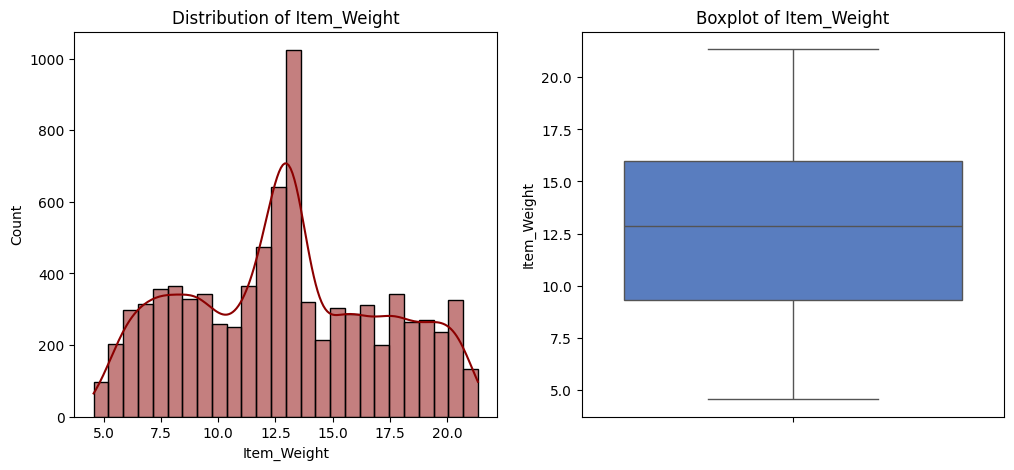

In [101]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.title("Distribution of Item_Weight")
sns.histplot(df['Item_Weight'],kde=True,color='darkred')

plt.subplot(122)
plt.title("Boxplot of Item_Weight")
sns.boxplot(df['Item_Weight'],palette="muted")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_59648\2248718250.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Item_Visibility'],palette="rainbow")


<Axes: title={'center': 'Boxplot of Item_Visibility'}, ylabel='Item_Visibility'>

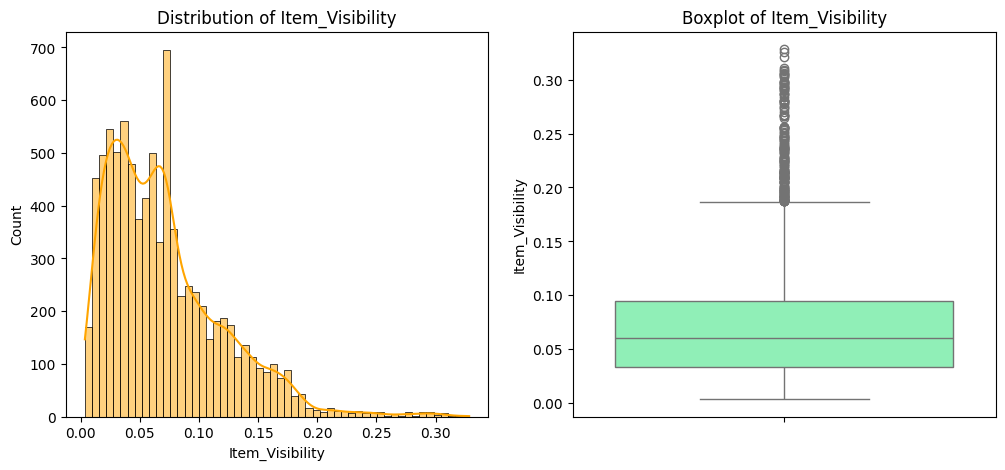

In [109]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.title("Distribution of Item_Visibility")
sns.histplot(df['Item_Visibility'],kde=True,color='orange')

plt.subplot(122)
plt.title("Boxplot of Item_Visibility")
sns.boxplot(df['Item_Visibility'],palette="rainbow")

##### **Observation :**
The distribution of Item_Visibility is left skewed and it contains several outliers.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_59648\214902208.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Item_MRP'],palette="Set3")


<Axes: title={'center': 'Boxplot of Item_MRP'}, ylabel='Item_MRP'>

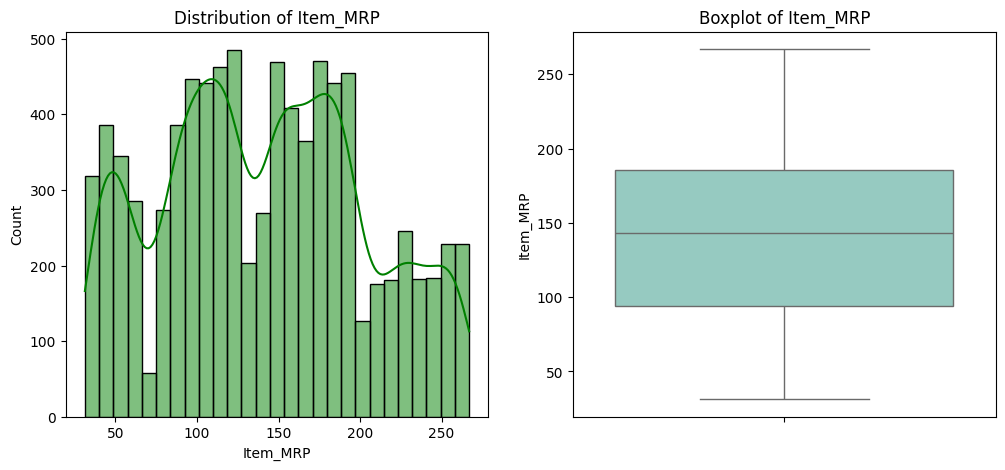

In [108]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.title("Distribution of Item_MRP")
sns.histplot(df['Item_MRP'],kde=True,color='green')

plt.subplot(122)
plt.title("Boxplot of Item_MRP")
sns.boxplot(df['Item_MRP'],palette="Set3")

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_59648\2080481321.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Outlet_Age'],palette="Set2")


<Axes: title={'center': 'Boxplot of Outlet_Age'}, ylabel='Outlet_Age'>

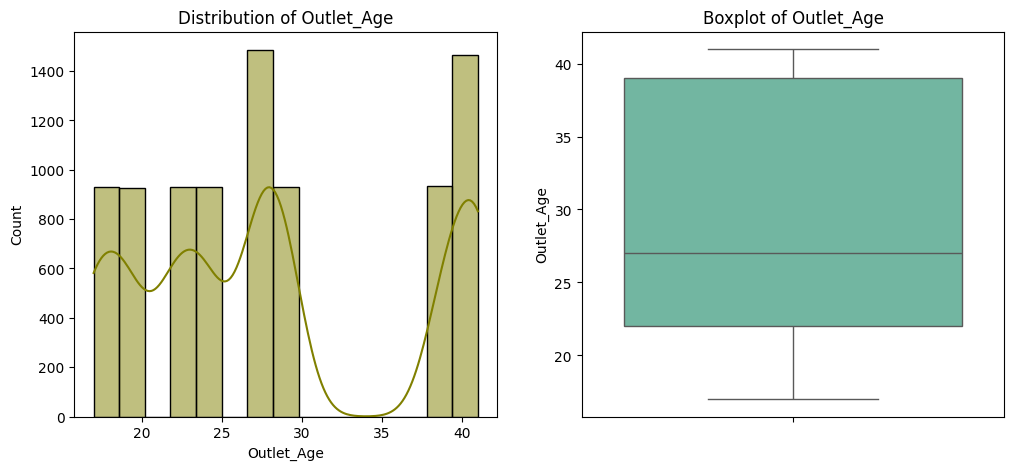

In [112]:
plt.figure(figsize=(12,5))

plt.subplot(121)
plt.title("Distribution of Outlet_Age")
sns.histplot(df['Outlet_Age'],kde=True,color='olive')

plt.subplot(122)
plt.title("Boxplot of Outlet_Age")
sns.boxplot(df['Outlet_Age'],palette="Set2")

#### Univariate Analysis for Categorical Variables

<Axes: title={'center': 'Countplot of Item_Fat_Content'}, xlabel='Item_Fat_Content', ylabel='count'>

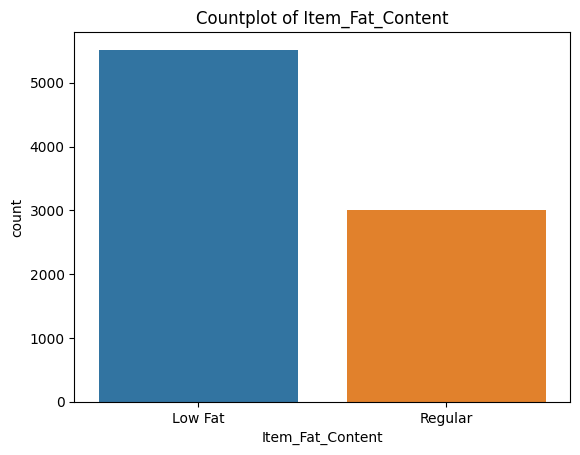

In [116]:
plt.title("Countplot of Item_Fat_Content")
sns.countplot(x='Item_Fat_Content',data=df,hue='Item_Fat_Content')

<Axes: title={'center': 'Countplot of Item_Type'}, xlabel='count', ylabel='Item_Type'>

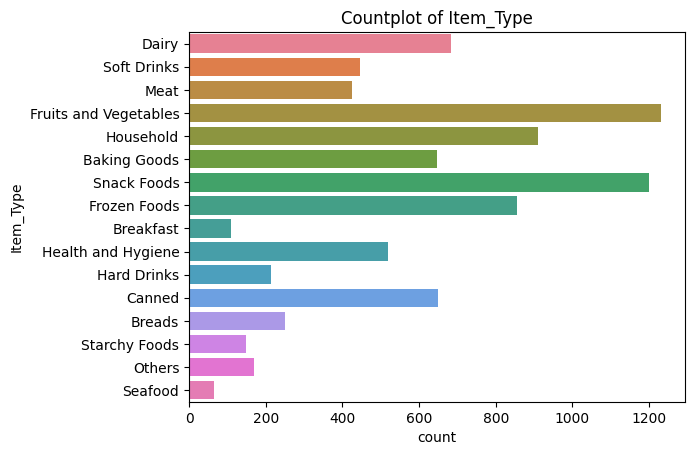

In [ ]:
plt.title("Countplot of Item_Type")
sns.countplot(y='Item_Type',data=df,hue='Item_Type')

<Axes: title={'center': 'Countplot of Outlet_Size'}, xlabel='Outlet_Size', ylabel='count'>

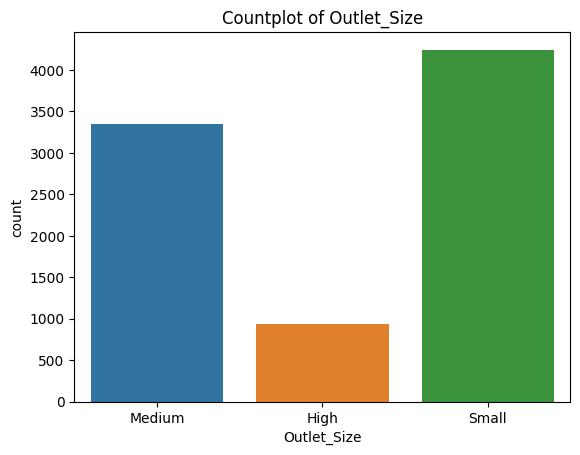

In [120]:
plt.title("Countplot of Outlet_Size")
sns.countplot(x='Outlet_Size',data=df,hue='Outlet_Size')

<Axes: title={'center': 'countplot of Outlet_Location_Type'}, xlabel='Outlet_Location_Type', ylabel='count'>

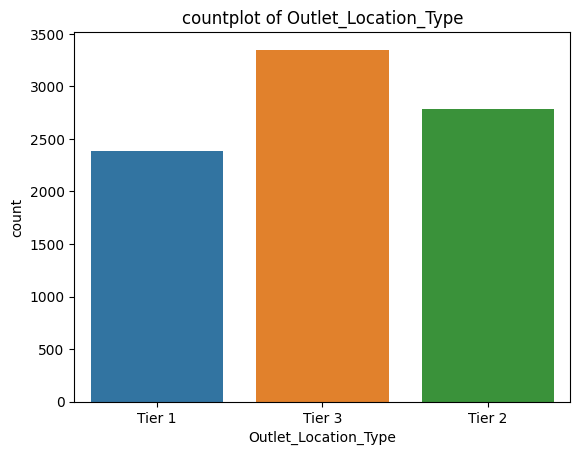

In [121]:
plt.title("countplot of Outlet_Location_Type")
sns.countplot(x='Outlet_Location_Type',data=df,hue='Outlet_Location_Type')

<Axes: title={'center': 'Countplot of Outlet_Type'}, xlabel='Outlet_Type', ylabel='count'>

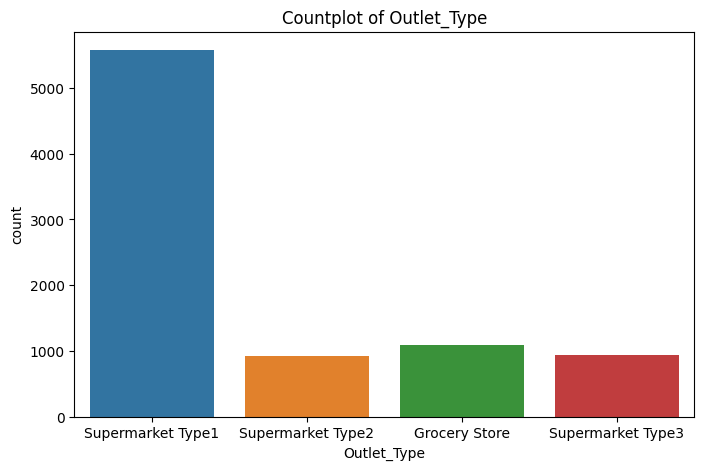

In [125]:
plt.figure(figsize=(8,5))
plt.title("Countplot of Outlet_Type")
sns.countplot(x='Outlet_Type',data=df,hue='Outlet_Type')

#### Bivariate Analysis

<Axes: title={'center': 'Countplot of Item_Type of different Item_Fat_Content'}, xlabel='count', ylabel='Item_Type'>

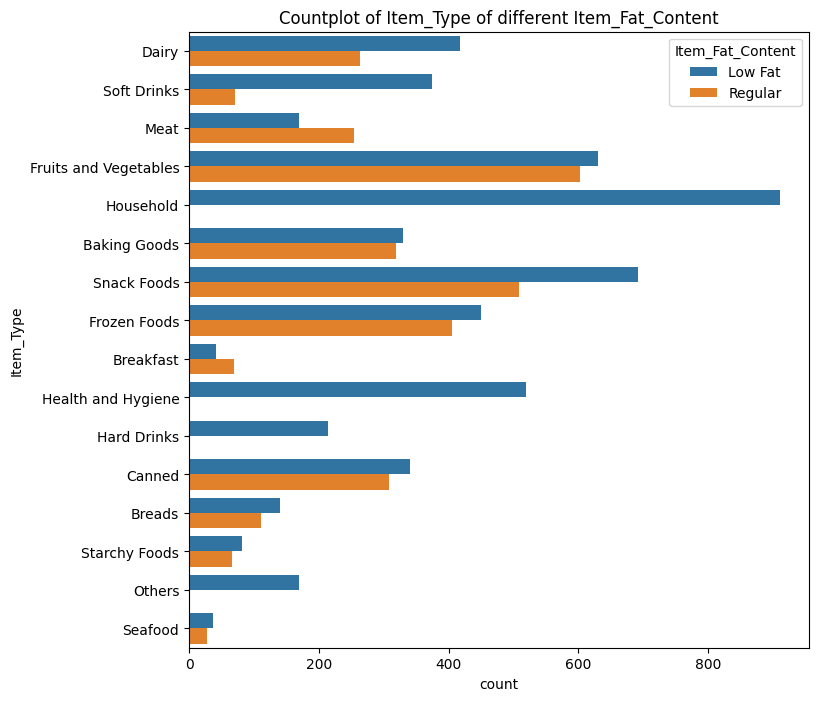

In [127]:
plt.figure(figsize=(8,8))
plt.title("Countplot of Item_Type of different Item_Fat_Content")
sns.countplot(y='Item_Type',data=df,hue='Item_Fat_Content')

<Axes: title={'center': 'Barplot of Item MRP vs Item_Type'}, xlabel='Item_MRP', ylabel='Item_Type'>

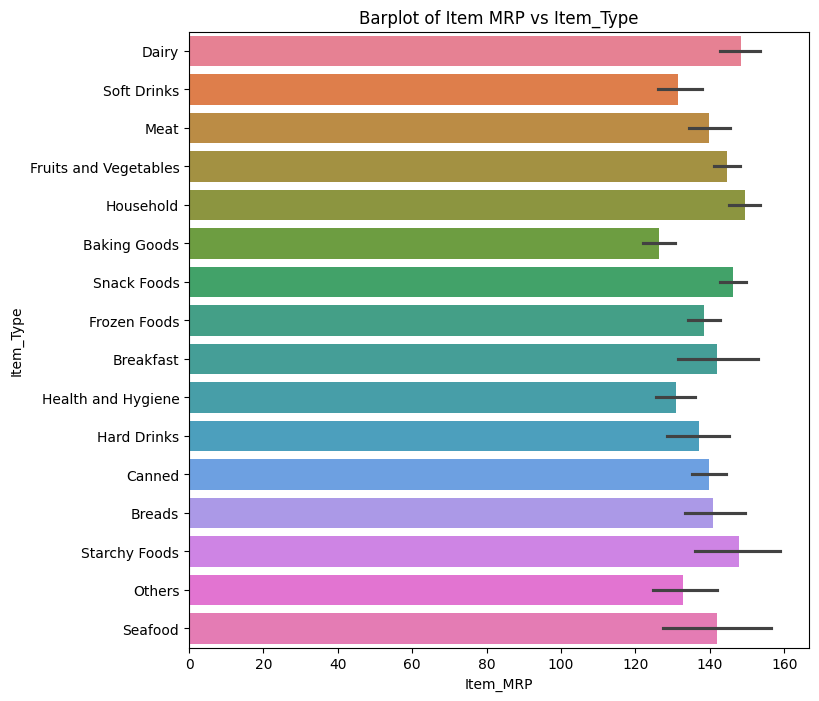

In [130]:
plt.figure(figsize=(8,8))
plt.title("Barplot of Item MRP vs Item_Type")
sns.barplot(y='Item_Type',x='Item_MRP',data=df,hue='Item_Type')

<Axes: title={'center': 'Countplot of Outlet_Type of different Outlet_Location_Type'}, xlabel='Outlet_Type', ylabel='count'>

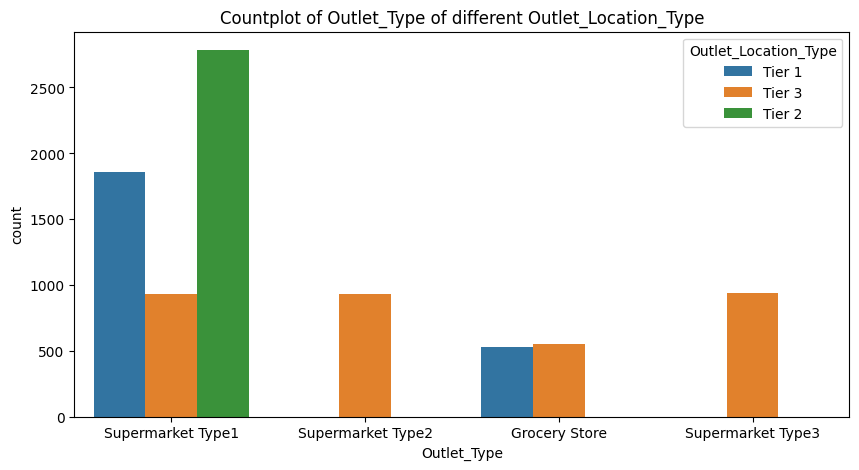

In [140]:
plt.figure(figsize=(10,5))
plt.title("Countplot of Outlet_Type of different Outlet_Location_Type")
sns.countplot(x='Outlet_Type',hue='Outlet_Location_Type',data=df)

<Axes: title={'center': 'Barplot of Outlet_Type Vs Outlet_Age'}, xlabel='Outlet_Type', ylabel='Outlet_Age'>

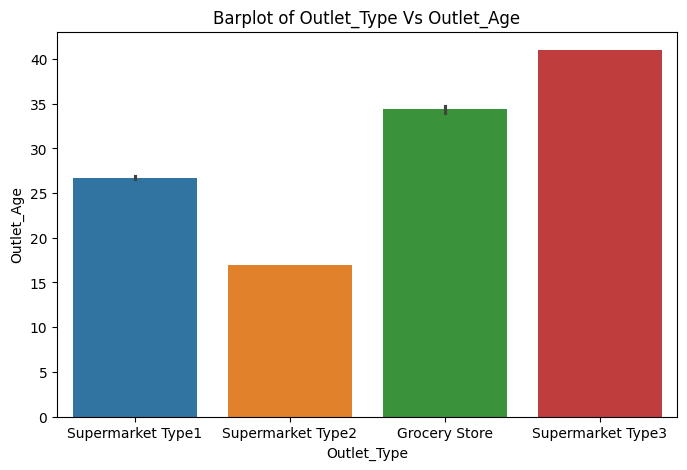

In [144]:
plt.figure(figsize=(8,5))
plt.title("Barplot of Outlet_Type Vs Outlet_Age")
sns.barplot(x='Outlet_Type',y='Outlet_Age',data=df,hue='Outlet_Type')